# Evaluation: LLM Classification vs. Gold Standard

Five steps: Compliance → Accuracy (SPF F1, crisis_ref) → Krippendorff α → Confusion matrices → Factorial decomposition.

Run from the `4_analysis/` directory so that `step4_evaluate` is importable.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))  # make step4_evaluate importable
from step4_evaluate import (
    CLASSIF_DIR, GOLD_PATH, RESULTS_DIR, VALID_SPF, MIN_COMPLIANCE,
    load_gold, load_runs, _compliance_rate,
    step1_compliance, step2_accuracy, step3_alpha,
    step4_confusion, step5_factorial,
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'plots').mkdir(exist_ok=True)

gold     = load_gold(GOLD_PATH)
runs     = load_runs(CLASSIF_DIR)
gold_ids = list(gold.keys())

print(f'Gold standard entries : {len(gold_ids)}')
print(f'Classification runs   : {len(runs)}')
print(f'Partial runs          : {sum(r["is_partial"] for r in runs)}')
print('Models:', sorted({r['model'] for r in runs}))
print(f'\nCompliance threshold  : {MIN_COMPLIANCE}')
masked = [(r['model'], r['prompt_key']) for r in runs if _compliance_rate(r, gold_ids) < MIN_COMPLIANCE]
print(f'Runs masked in steps 2-5 ({len(masked)}):')
for model, prompt in masked:
    print(f'  {model}  |  {prompt}')

Gold standard entries : 67
Classification runs   : 48
Partial runs          : 0
Models: ['gpt-4.1-mini', 'meta-llama/Llama-3.3-70B-Instruct', 'mistral-large-3-675b-instruct-2512']

Compliance threshold  : 0.8
Runs masked in steps 2-5 (12):
  meta-llama/Llama-3.3-70B-Instruct  |  v1_zero_shot_batch_nodef_nojus
  meta-llama/Llama-3.3-70B-Instruct  |  v3_zero_shot_batch_def_nojus
  meta-llama/Llama-3.3-70B-Instruct  |  v4_zero_shot_single_def_nojus
  meta-llama/Llama-3.3-70B-Instruct  |  v5_zero_shot_batch_nodef_jus
  meta-llama/Llama-3.3-70B-Instruct  |  v7_zero_shot_batch_def_jus
  meta-llama/Llama-3.3-70B-Instruct  |  v8_zero_shot_single_def_jus
  mistral-large-3-675b-instruct-2512  |  v1_zero_shot_batch_nodef_nojus
  mistral-large-3-675b-instruct-2512  |  v3_zero_shot_batch_def_nojus
  mistral-large-3-675b-instruct-2512  |  v4_zero_shot_single_def_nojus
  mistral-large-3-675b-instruct-2512  |  v5_zero_shot_batch_nodef_jus
  mistral-large-3-675b-instruct-2512  |  v7_zero_shot_batch_def

## Step 1 — Compliance

Per-model summary (across all prompts):


,mean,min,max
model,,,
gpt-4.1-mini,1.000,1.0,1.000
meta-llama/Llama-3.3-70B-Instruct,0.578,0.0,0.985
mistral-large-3-675b-instruct-2512,0.679,0.0,1.000


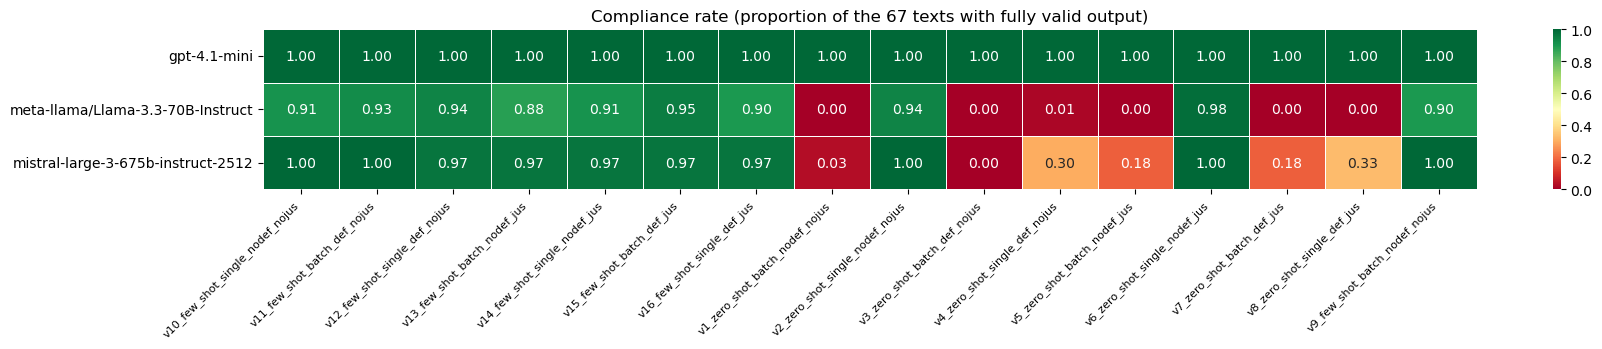

In [2]:
heatmap, summary = step1_compliance(runs, gold_ids)
heatmap.to_csv(RESULTS_DIR / 'compliance_heatmap.csv')
summary.to_csv(RESULTS_DIR / 'compliance_summary.csv')

print('Per-model summary (across all prompts):')
display(summary)

fig, ax = plt.subplots(figsize=(18, max(3, len(heatmap) * 1.2)))
sns.heatmap(
    heatmap, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.4, ax=ax,
)
ax.set_title('Compliance rate (proportion of the 67 texts with fully valid output)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / 'compliance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2 — Accuracy

In [3]:
macro_f1_df, exact_match_df, crisis_f1_df, per_cat_df = step2_accuracy(runs, gold)

macro_f1_df.to_csv(RESULTS_DIR / 'spf_macro_f1.csv')
exact_match_df.to_csv(RESULTS_DIR / 'spf_exact_match.csv')
crisis_f1_df.to_csv(RESULTS_DIR / 'crisis_ref_f1.csv')
per_cat_df.to_csv(RESULTS_DIR / 'spf_per_category_f1_best_prompt.csv')

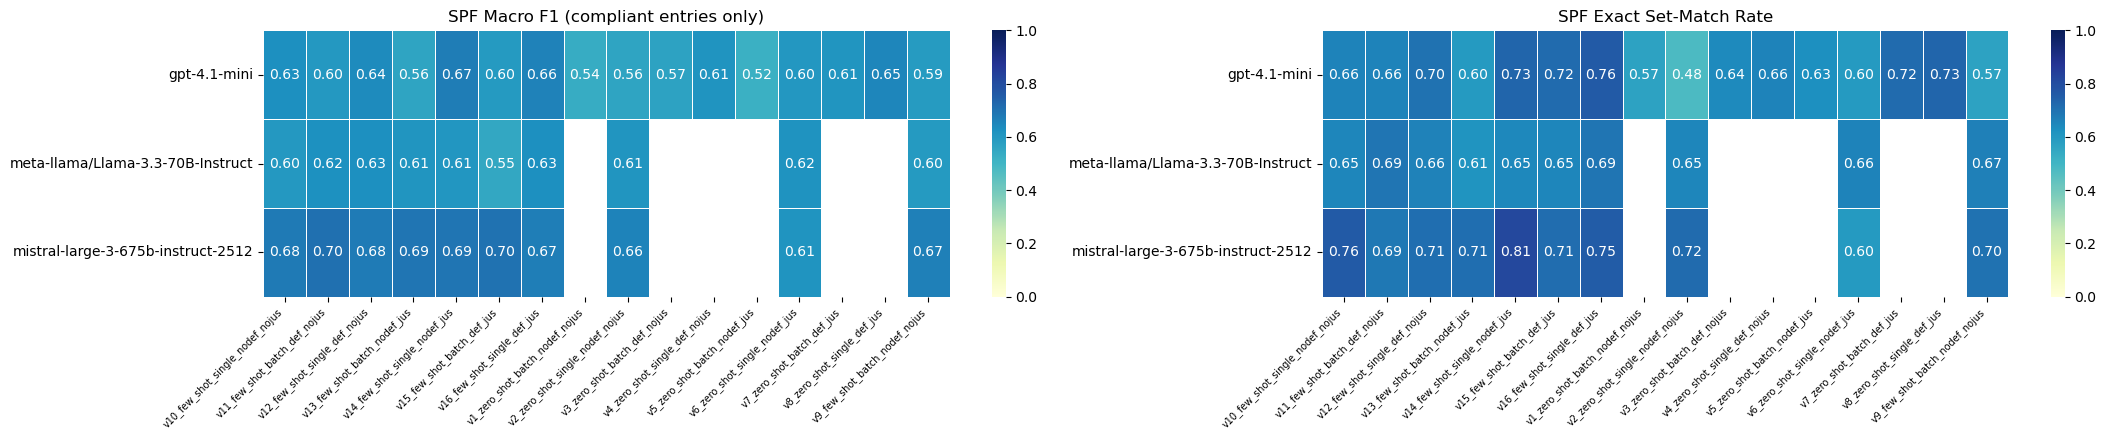

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(22, max(3, len(macro_f1_df) * 1.5)))

for ax, df, title in zip(
    axes,
    [macro_f1_df, exact_match_df],
    ['SPF Macro F1 (compliant entries only)', 'SPF Exact Set-Match Rate (compliant entries only)'],
):
    sns.heatmap(
        df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1,
        linewidths=0.4, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / 'spf_accuracy_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

Per-category F1 — best prompt per model:


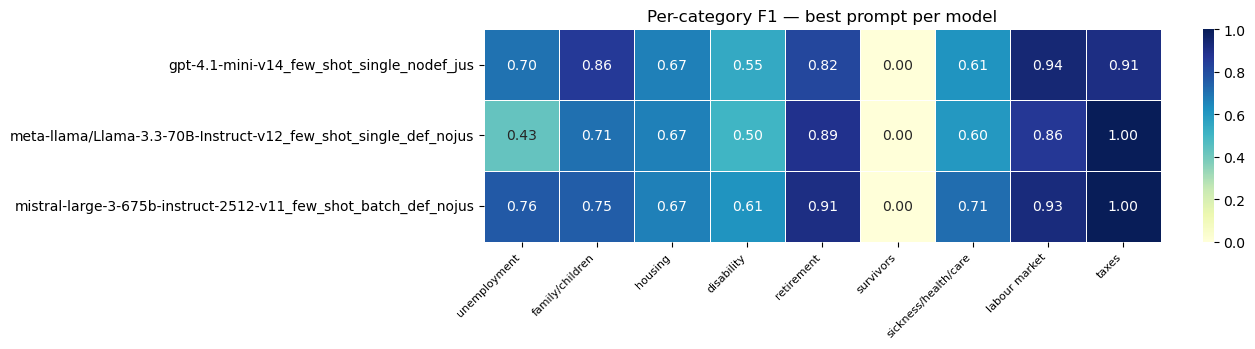

In [5]:
print('Per-category F1 — best prompt per model:')
fig, ax = plt.subplots(figsize=(max(10, len(per_cat_df.columns) * 1.5), max(3, len(per_cat_df) * 1.2)))
sns.heatmap(
    per_cat_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1,
    linewidths=0.4, ax=ax,
)
ax.set_title('Per-category F1 — best prompt per model')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / 'spf_per_category_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print('Per-category F1 — best prompt per model:')
display(per_cat_df.style.format('{:.2f}').background_gradient(cmap='YlGnBu', axis=None, vmin=0, vmax=1))

Per-category F1 — best prompt per model:


,,unemployment,family/children,housing,disability,retirement,survivors,sickness/health/care,labour market,taxes
model,prompt_key,,,,,,,,,
gpt-4.1-mini,v14_few_shot_single_nodef_jus,0.70,0.86,0.67,0.55,0.82,0.00,0.61,0.94,0.91
meta-llama/Llama-3.3-70B-Instruct,v12_few_shot_single_def_nojus,0.43,0.71,0.67,0.50,0.89,0.00,0.60,0.86,1.00
mistral-large-3-675b-instruct-2512,v11_few_shot_batch_def_nojus,0.76,0.75,0.67,0.61,0.91,0.00,0.71,0.93,1.00


## Step 3 — Krippendorff's α

In [ ]:
alpha_spf_bin_df, alpha_spf_nom_df, alpha_cr_df = step3_alpha(runs, gold)

alpha_spf_bin_df.to_csv(RESULTS_DIR / 'alpha_spf_binary.csv')
alpha_spf_nom_df.to_csv(RESULTS_DIR / 'alpha_spf_nominal.csv')
alpha_cr_df.to_csv(RESULTS_DIR  / 'alpha_crisis_ref.csv')

fig, axes = plt.subplots(1, 3, figsize=(32, max(3, len(alpha_spf_bin_df) * 1.5)))

for ax, df, title in zip(
    axes,
    [alpha_spf_bin_df, alpha_spf_nom_df, alpha_cr_df],
    [
        'Krippendorff α — SPF binary (avg over 9 categories)',
        'Krippendorff α — SPF nominal (field_1 only)',
        'Krippendorff α — crisis_ref binary (batch only)',
    ],
):
    sns.heatmap(
        df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
        center=0, linewidths=0.4, ax=ax,
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / 'alpha_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Confusion Matrices (best prompt per model)

In [ ]:
step4_confusion(macro_f1_df, runs, gold, RESULTS_DIR / 'plots')

# Display the saved PNGs inline
from IPython.display import Image, display as ipy_display
for png in sorted((RESULTS_DIR / 'plots').glob('confusion_*.png')):
    print(png.stem)
    ipy_display(Image(filename=str(png)))

## Step 5 — Factorial Decomposition

In [ ]:
factorial = step5_factorial(macro_f1_df, alpha_spf_bin_df)
factorial.to_csv(RESULTS_DIR / 'factorial_decomposition.csv')

display(
    factorial.style
    .format('{:.3f}')
    .background_gradient(subset=['avg_macro_f1'],  cmap='YlGnBu', vmin=0, vmax=1)
    .background_gradient(subset=['avg_alpha_spf'], cmap='RdYlGn', vmin=-0.5, vmax=1)
)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
dims = ['shot', 'scope', 'def', 'jus']
dim_ticks = ['zero/few-shot', 'batch/single', 'no-def/def', 'no-jus/jus']

for ax, col, title in zip(
    axes,
    ['avg_macro_f1', 'avg_alpha_spf'],
    ['Avg Macro F1', 'Avg Krippendorff α (SPF binary)'],
):
    x = range(len(dims))
    vals0 = [factorial.loc[(d, factorial.loc[d].index[0]), col] for d in dims]
    vals1 = [factorial.loc[(d, factorial.loc[d].index[1]), col] for d in dims]
    width = 0.35
    ax.bar([xi - width/2 for xi in x], vals0, width, label='feature=0')
    ax.bar([xi + width/2 for xi in x], vals1, width, label='feature=1')
    ax.set_xticks(list(x))
    ax.set_xticklabels(dim_ticks, rotation=20, ha='right')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / 'factorial_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()